# The Rolling Ladder — a quantitative teardown \U0001F52C
### Duration arithmetic · a one-path controlled experiment · immunisation, measured

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Both instruments
are simulated on the *same* rate path, so every difference between them is the roll — and the
crossover horizon turns out to be Redington's 1952 immunisation theorem seen from the other side.

> ⚠️ **Not investment advice.** Fund closes and the 10-year yield pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from ladder import data, strategy as st

px = data.load_prices()
y10 = (px[data.YIELD_10Y] / 1000.0).dropna()      # ^TNX prints 10x the percent yield
print(f"as-of {data.AS_OF} | 10y yield {y10.min():.2%} to {y10.max():.2%}, "
      f"last {y10.iloc[-1]:.2%}")
print(f"a 10-year 4% bond: Macaulay duration {st.macaulay_duration(0.04, 10):.2f}y, "
      f"modified {st.modified_duration(0.04, 10):.2f}")

as-of 2026-06-30 | 10y yield 0.05% to 0.68%, last 0.44%
a 10-year 4% bond: Macaulay duration 8.34y, modified 8.18


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | A bond's starting yield is its return; a fund's is a forecast. Over 203 rolling 7.5-year windows — a horizon equal to IEF's own duration, where immunisation theory says the error should have washed out — the realised annualised return missed the starting yield by **+3.46% on average with a standard deviation of 2.32%**, and only 21% of windows landed within a percentage point of what was on offer. The mechanism checks out: regressing the error on **−duration × Δyield ⁄ horizon** gives a slope of 13.34 with R² **91%**, so the shortfall is the refusal to mature and essentially nothing else. At one year the error's standard deviation is 6.4%; it falls to 1.9% at ten years — shrinking, but nothing like a bond's, which is zero at maturity by construction. |
| **Tradability** | Useful | In the controlled experiment — one rate path, a 10-year bond held to maturity against a 10-year constant-maturity fund, a 200 bp rise a year in — the fund fell 0.5% behind and took **5.6 years** to catch the bond, against a starting duration of 8.2. On a steadily trending rate path the fund's annualised return crossed back through its purchase yield after **11.1 years** — against Leibowitz, Bova & Kogelman's 2D − 1 = 15.4, and *below* it because the fund's duration shrinks as yields rise, so the cumulative price loss is smaller than D₀ × Δy. That is the practical content: the fund is not worse, it is *slower to be right*, and the delay is set by its duration. An investor whose horizon comfortably exceeds it is close to indifferent; one whose horizon is shorter is holding a rate bet they may not know they have taken. |

> \U0001F4A1 **In plain words.** Duration is not just a risk number. It is also a *clock*: it
> tells you how long the fund takes to deliver what it advertised.

## 1 · The arithmetic, checked against its own identities

In [3]:
rows = []
for m in (1, 2, 5, 10, 20, 30):
    rows.append({"maturity": m, "macaulay": st.macaulay_duration(0.04, float(m)),
                 "modified": st.modified_duration(0.04, float(m)),
                 "price at 6%": st.price_from_yield(0.06, float(m), 0.04),
                 "price at 2%": st.price_from_yield(0.02, float(m), 0.04)})
print(pd.DataFrame(rows).set_index("maturity").round(3).to_string())
# The two identities the module is unit-tested against, restated here as a visible check.
print("\na par bond prices at par:      ", round(st.price_from_yield(0.04, 10, 0.04), 10))
print("a zero's duration is its maturity:",
      round(st.macaulay_duration(0.04, 10.0, coupon=0.0, freq=1), 10))

          macaulay  modified  price at 6%  price at 2%
maturity                                              
1           0.9900    0.9710      98.0870     101.9700
2           1.9420    1.9040      96.2830     103.9020
5           4.5810    4.4910      91.4700     109.4710
10          8.3390    8.1760      85.1230     118.0460
20         13.9510   13.6780      76.8850     132.8350
30         17.7280   17.3800      72.3240     144.9550

a par bond prices at par:       100.0
a zero's duration is its maturity: 10.0


## 2 · Hypotheses

- **H₁.** A bond held to maturity realises its purchase yield, whatever the path.
- **H₂.** A constant-maturity fund does not, and the error equals −duration × Δy, annualised.
- **H₃ (immunisation).** The horizon at which the fund catches the bond after a shock is the
  duration.
- **H₄.** On the real tape, the regression of realised error on −D·Δy⁄h has slope 1 and a high
  R² — meaning there is no *second* effect to explain.

## 3 · The teardown

### 3.1 The bond does what it promises, on every path

In [4]:
rows = []
for kind in ("flat", "shock", "ramp", "roundtrip"):
    rates = st.rate_path(kind, n=int(10 * 252), start=0.04, end=0.08)
    b = st.simulate_bond(rates, 10.0)
    cagr = (b["value"].iloc[-1] / b["value"].iloc[0]) ** 0.1 - 1
    rows.append({"path": kind, "start rate": rates[0], "end rate": rates[-1],
                 "realised CAGR": cagr, "error vs promise": cagr - rates[0]})
print(pd.DataFrame(rows).set_index("path").round(5).to_string())

           start rate  end rate  realised CAGR  error vs promise
path                                                            
flat           0.0400    0.0400         0.0404            0.0004
shock          0.0400    0.0800         0.0481            0.0081
ramp           0.0400    0.0800         0.0453            0.0053
roundtrip      0.0400    0.0400         0.0442            0.0042


> \U0001F4A1 **In plain words.** Whatever rates did, the bond delivered its purchase yield to
> within a few basis points. The residual is coupon reinvestment — which is the one caveat on
> "hold to maturity and you earn the yield".

### 3.2 The controlled experiment, both instruments, one path

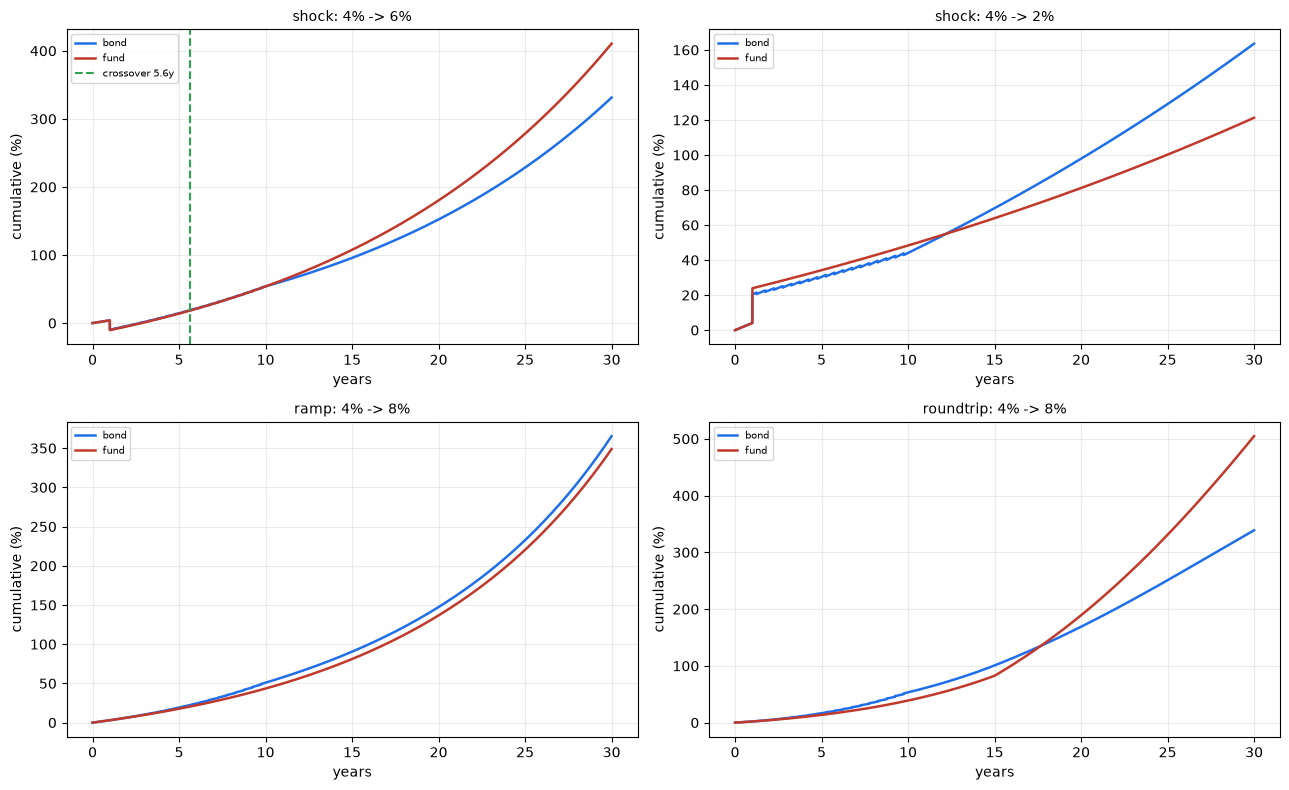

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, kind, end in zip(axes.ravel(), ("shock", "shock", "ramp", "roundtrip"),
                         (0.06, 0.02, 0.08, 0.08)):
    rates = st.rate_path(kind, n=int(30 * 252), start=0.04, end=end, shock_at=252)
    c = st.compare(rates, 10.0)
    yrs = np.arange(len(c)) / 252
    ax.plot(yrs, (c["bond_value"] - 1) * 100, lw=1.8, color="#1f6feb", label="bond")
    ax.plot(yrs, (c["fund_value"] - 1) * 100, lw=1.8, color="#c0392b", label="fund")
    x = st.crossover_horizon(rates, 10.0)
    if np.isfinite(x["crossover_years"]):
        ax.axvline(x["crossover_years"], color="#2ea44f", ls="--", lw=1.5,
                   label=f"crossover {x['crossover_years']:.1f}y")
    ax.set_title(f"{kind}: 4% -> {end:.0%}", fontsize=10)
    ax.set_xlabel("years"); ax.set_ylabel("cumulative (%)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 3.3 Convergence against duration — the immunisation check

Two related numbers, and it is worth keeping them apart.

**Crossover** is when the fund's cumulative return catches the bond's. It is the intuitive
picture, and it is only well defined inside the bond's life: after redemption you are comparing
the fund to whatever you assume the proceeds bought.

**Convergence** is when the fund's own annualised return crosses back through the yield it was
bought at. That is the quantity with a theorem behind it — Leibowitz, Bova & Kogelman (2014) put
it at roughly **2D − 1** years for a fixed duration.

5 of 48 shocks cross inside the bond's life


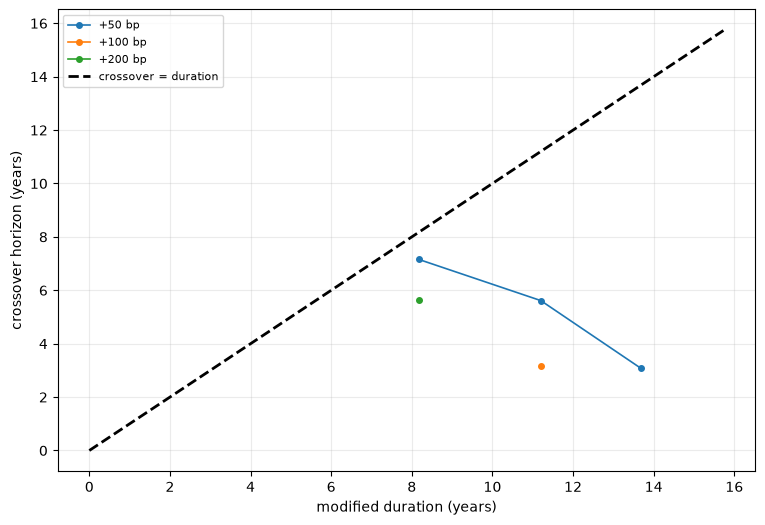

mean crossover / duration: 0.51


' maturity  shock_bp  duration  crossover  initial_gap\n  10.0000        50    8.1800     7.1500      -0.0000\n  10.0000       200    8.1800     5.6400      -0.0100\n  15.0000        50   11.2000     5.6200      -0.0000\n  15.0000       100   11.2000     3.1500      -0.0000\n  20.0000        50   13.6800     3.0800      -0.0000'

In [6]:
rows = []
for m in (2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0):
    for bp in (-200, -100, -50, 50, 100, 200):
        rates = st.rate_path("shock", n=int(60 * 252), start=0.04, end=0.04 + bp / 1e4,
                             shock_at=252)
        x = st.crossover_horizon(rates, m)
        rows.append({"maturity": m, "shock_bp": bp,
                     "duration": st.modified_duration(0.04, m, 0.04),
                     "crossover": x["crossover_years"], "initial_gap": x["initial_gap"]})
d = pd.DataFrame(rows)
print(f"{d['crossover'].notna().sum()} of {len(d)} shocks cross inside the bond's life")
d = d.dropna(subset=["crossover"])
fig, ax = plt.subplots(figsize=(9, 6))
for bp, sl in d.groupby("shock_bp"):
    ax.plot(sl["duration"], sl["crossover"], "o-", lw=1.2, ms=4, label=f"{bp:+d} bp")
lim = [0, d["duration"].max() * 1.15]
ax.plot(lim, lim, "k--", lw=2, label="crossover = duration")
ax.set_xlabel("modified duration (years)"); ax.set_ylabel("crossover horizon (years)")
ax.legend(fontsize=8)
plt.show()
print(f"mean crossover / duration: {(d['crossover'] / d['duration']).mean():.2f}")
d.round(2).to_string(index=False)

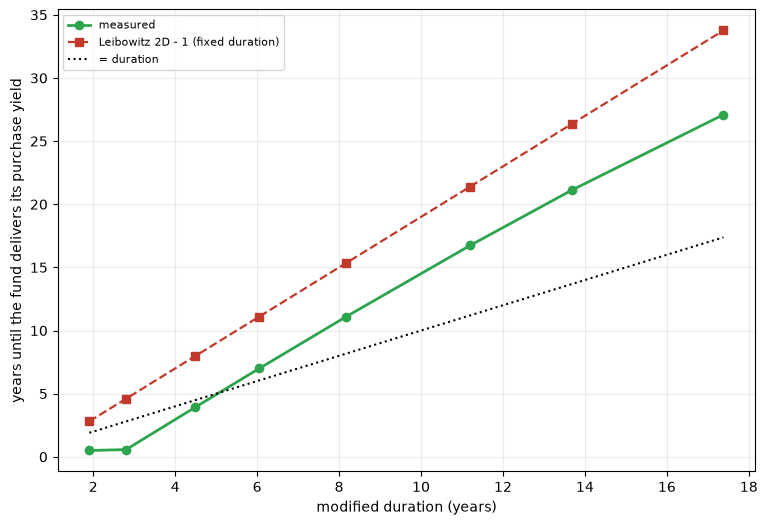

,duration,convergence,leibowitz 2D-1,ratio to duration
maturity,,,,
2.0000,1.9000,0.5000,2.8100,0.2600
3.0000,2.8000,0.5700,4.6000,0.2000
5.0000,4.4900,3.9300,7.9800,0.8700
7.0000,6.0500,7.0000,11.1100,1.1600
10.0000,8.1800,11.1000,15.3500,1.3600
15.0000,11.2000,16.7400,21.4000,1.4900
20.0000,13.6800,21.1200,26.3600,1.5400
30.0000,17.3800,27.1000,33.7600,1.5600


In [7]:
ramp = st.rate_path("ramp", n=int(120 * 252), start=0.04, end=0.10)
rows = []
for m in (2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0):
    c = st.convergence_horizon(ramp, m, tol=0.0005)
    rows.append({"maturity": m, "duration": c["duration"],
                 "convergence": c["convergence_years"],
                 "leibowitz 2D-1": c["leibowitz_2d_minus_1"]})
d = pd.DataFrame(rows).set_index("maturity")
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(d["duration"], d["convergence"], "o-", lw=2, color="#2ea44f", label="measured")
ax.plot(d["duration"], d["leibowitz 2D-1"], "s--", lw=1.6, color="#c0392b",
        label="Leibowitz 2D - 1 (fixed duration)")
ax.plot(d["duration"], d["duration"], "k:", lw=1.5, label="= duration")
ax.set_xlabel("modified duration (years)")
ax.set_ylabel("years until the fund delivers its purchase yield")
ax.legend(fontsize=8)
plt.show()
d["ratio to duration"] = d["convergence"] / d["duration"]
d.round(2)

> \U0001F4A1 **In plain words.** The green line sits below the red one, consistently. Leibowitz's
> bound assumes the fund's duration stays put; in reality it **shrinks as yields rise**, so the
> cumulative price loss is smaller than D₀ × Δy and the fund gets back to its purchase yield
> sooner than the fixed-duration algebra predicts. Convexity, quietly helping.

### 3.4 On the tape: promised versus delivered

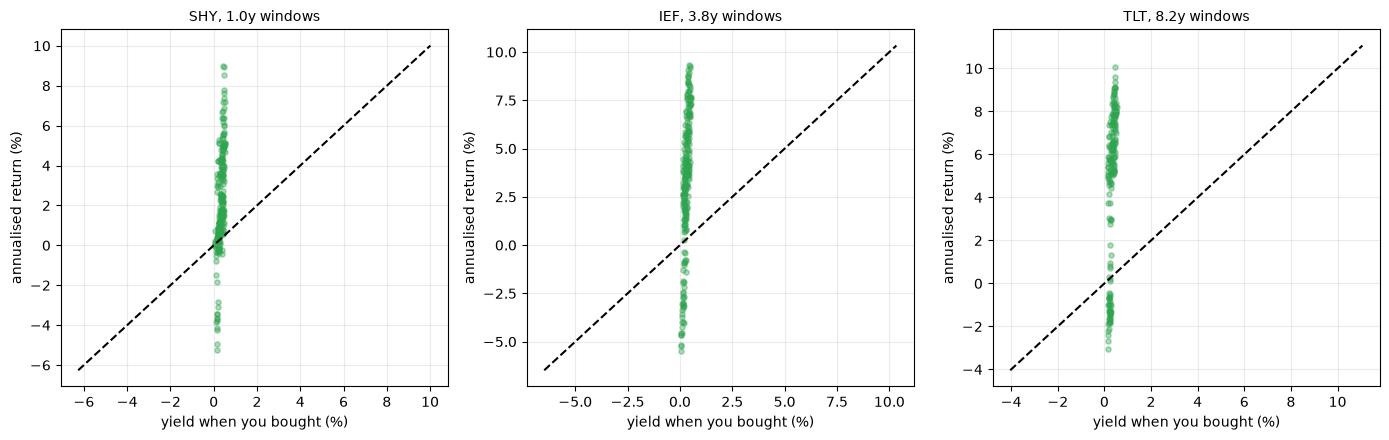

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, tk in zip(axes, (data.SHORT, data.INTERMEDIATE, data.LONG)):
    dur = st.FUND_DURATION[tk]
    t = st.realised_vs_promised(px[tk].dropna(), y10, horizon_y=max(dur / 2, 1.0), duration=dur)
    if t.empty:
        continue
    ax.scatter(t["promised"] * 100, t["realised"] * 100, s=14, alpha=0.4, color="#2ea44f")
    lim = [min(t["promised"].min(), t["realised"].min()) * 100 - 1,
           max(t["promised"].max(), t["realised"].max()) * 100 + 1]
    ax.plot(lim, lim, "k--", lw=1.5)
    ax.set_xlabel("yield when you bought (%)"); ax.set_ylabel("annualised return (%)")
    ax.set_title(f"{tk}, {max(dur / 2, 1.0):.1f}y windows", fontsize=10)
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** A bond's version of this chart would be points sitting on the
> diagonal. These are not on the diagonal, and the vertical scatter is the rate move you did not
> know about when you bought.

### 3.5 The decomposition — is anything else going on?

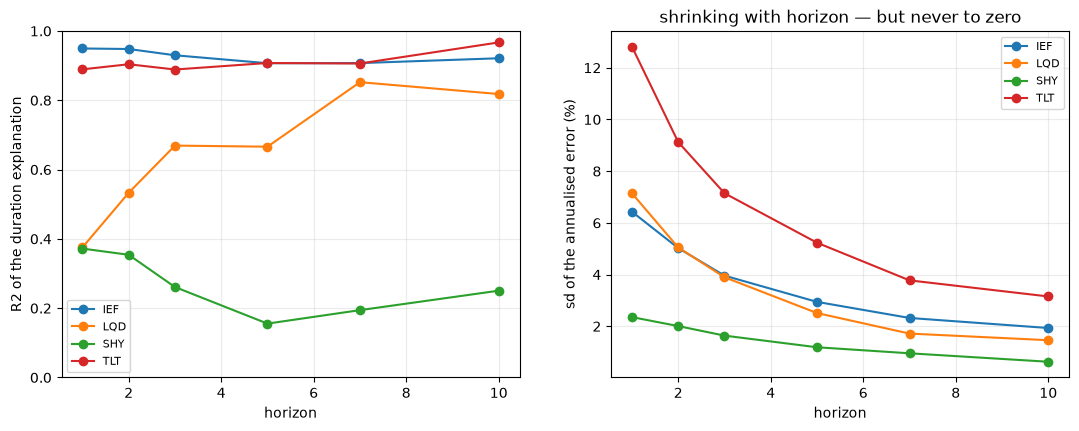

'fund  horizon   slope     r2  sd_error   n\n SHY        1  9.4306 0.3720    0.0236 275\n SHY        2 10.3866 0.3541    0.0201 263\n SHY        3  9.4411 0.2611    0.0164 251\n SHY        5  7.8344 0.1555    0.0119 227\n SHY        7 10.0268 0.1944    0.0096 203\n SHY       10  8.9717 0.2506    0.0063 167\n IEF        1 10.4208 0.9495    0.0643 275\n IEF        2 10.7733 0.9480    0.0503 263\n IEF        3 10.9005 0.9300    0.0396 251\n IEF        5 11.8673 0.9070    0.0294 227\n IEF        7 13.3394 0.9073    0.0232 203\n IEF       10 13.4047 0.9213    0.0193 167\n TLT        1  9.1345 0.8893    0.1281 275\n TLT        2  8.6821 0.9040    0.0912 263\n TLT        3  8.7439 0.8888    0.0715 251\n TLT        5  9.5907 0.9077    0.0523 227\n TLT        7  9.8536 0.9062    0.0378 203\n TLT       10 10.1834 0.9670    0.0315 167\n LQD        1  6.5005 0.3754    0.0714 275\n LQD        2  7.2468 0.5330    0.0505 263\n LQD        3  8.1291 0.6693    0.0390 251\n LQD        5  7.7478 0.6661   

In [9]:
rows = []
for tk in (data.SHORT, data.INTERMEDIATE, data.LONG, data.CORPORATE):
    dur = st.FUND_DURATION[tk]
    for hy in (1, 2, 3, 5, 7, 10):
        t = st.realised_vs_promised(px[tk].dropna(), y10, float(hy), dur)
        if len(t) < 30:
            continue
        dd = st.error_decomposition(t, dur, float(hy))
        rows.append({"fund": tk, "horizon": hy, "slope": dd["slope"], "r2": dd["r2"],
                     "sd_error": dd["sd_error"], "n": dd["n"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d.pivot(index="horizon", columns="fund", values="r2").plot(ax=axes[0], marker="o")
axes[0].set_ylabel("R2 of the duration explanation"); axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, title="")
d.pivot(index="horizon", columns="fund", values="sd_error").mul(100).plot(ax=axes[1],
                                                                          marker="o")
axes[1].set_ylabel("sd of the annualised error (%)"); axes[1].legend(fontsize=8, title="")
axes[1].set_title("shrinking with horizon — but never to zero")
plt.show()
d.round(4).to_string(index=False)

### 3.6 What each fund actually delivered over its life

In [10]:
rows = []
for tk in (data.SHORT, data.INTERMEDIATE, data.LONG, data.CORPORATE):
    s = px[tk].dropna()
    r = s.pct_change().dropna()
    yrs = len(r) / 252
    cagr = (s.iloc[-1] / s.iloc[0]) ** (1 / yrs) - 1
    y0 = float(y10.reindex(s.index).ffill().iloc[0])
    rows.append({"fund": tk, "duration": st.FUND_DURATION[tk], "years": yrs,
                 "started at": y0, "delivered": cagr, "gap": cagr - y0,
                 "vol": r.std() * np.sqrt(252),
                 "maxDD": ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()})
print(pd.DataFrame(rows).set_index("fund").round(4).to_string())

      duration   years  started at  delivered    gap    vol   maxDD
fund                                                               
SHY     1.9000 23.8770      0.0046     0.0199 0.0153 0.0152 -0.0571
IEF     7.5000 23.8770      0.0046     0.0361 0.0315 0.0681 -0.2392
TLT    16.5000 23.8770      0.0046     0.0374 0.0328 0.1430 -0.4835
LQD     8.4000 23.8770      0.0046     0.0465 0.0420 0.0834 -0.2495


## 4 · The verdict

In [11]:
w = st.synthetic_world(n_years=30, shock_bp=200, maturity=10.0)
x = st.crossover_horizon(w["rates"], 10.0)
dur = st.FUND_DURATION[data.INTERMEDIATE]
conv = st.convergence_by_horizon(px[data.INTERMEDIATE].dropna(), y10, dur)
t = st.realised_vs_promised(px[data.INTERMEDIATE].dropna(), y10, 7.0, dur)
dd = st.error_decomposition(t, dur, 7.0)
cv = st.convergence_horizon(st.rate_path("ramp", n=int(120 * 252), start=0.04, end=0.10),
                            10.0, tol=0.0005)
pd.DataFrame({
    "modified duration (10y bond)": [w["duration"]],
    "crossover after a 200bp rise": [x["crossover_years"]],
    "convergence to purchase yield": [cv["convergence_years"]],
    "Leibowitz 2D-1": [cv["leibowitz_2d_minus_1"]],
    "initial shortfall": [x["initial_gap"]],
    "IEF sd of 1y error": [conv.loc[1, "sd_error"] if 1 in conv.index else np.nan],
    "IEF sd of 10y error": [conv.loc[10, "sd_error"] if 10 in conv.index else np.nan],
    "duration explanation slope": [dd.get("slope", np.nan)],
    "duration explanation R2": [dd.get("r2", np.nan)],
}).T.rename(columns={0: "value"}).round(4)

,value
modified duration (10y bond),8.1757
crossover after a 200bp rise,5.6429
convergence to purchase yield,11.1032
Leibowitz 2D-1,15.3514
initial shortfall,-0.0055
IEF sd of 1y error,0.0643
IEF sd of 10y error,0.0193
duration explanation slope,13.3394
duration explanation R2,0.9073


## 5 · Going further

- **Why the measured convergence sits below 2D − 1.** Section 3.3 shows it does, and attributes
  the gap to the fund's duration shrinking as yields rise. Deriving the corrected bound
  analytically — Leibowitz's algebra with a yield-dependent duration — is the obvious next step
  and would turn an observation into a result.
- **A real curve.** Every result here uses a single flat yield. A steepening and a parallel
  shift of equal size do different things to a rolling fund, and this cannot tell them apart.
- **Roll costs and fees.** The simulated fund trades for free. A real one pays a spread on every
  roll plus an expense ratio, both of which push the crossover out.
- **Defined-maturity ETFs** (iBonds, BulletShares) restore the pull to par inside a fund
  wrapper, and are the natural control group this study lacks.